In [1]:
devtools::install_github("WorldWeatherAttribution/rwwa")

mvtnorm      (1.3-2    -> 1.3-3   ) [CRAN]
RcppArmad... (14.0.2-1 -> 14.4.1-1) [CRAN]
Rcpp         (1.0.13-1 -> 1.0.14  ) [CRAN]
pspline      (1.0-20   -> 1.0-21  ) [CRAN]
distillery   (1.2-1    -> 1.2-2   ) [CRAN]
copula       (1.1-4    -> 1.1-6   ) [CRAN]
extRemes     (2.1-4    -> 2.2     ) [CRAN]


Installing 7 packages: mvtnorm, RcppArmadillo, Rcpp, pspline, distillery, copula, extRemes

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



── R CMD build ───────────────────────────────────────────────────────────────────────────────────
✔  checking for file ‘/private/var/folders/h8/zzbvzz1s71v9gxlqp0my3f6c0000gn/T/RtmpDLm1de/remotes3e74139a2d74/WorldWeatherAttribution-rwwa-d40ae25/DESCRIPTION’
─  preparing ‘rwwa’:
✔  checking DESCRIPTION meta-information
─  checking for LF line-endings in source and make files and shell scripts
─  checking for empty or unneeded directories
   Omitted ‘LazyData’ from DESCRIPTION
─  building ‘rwwa_0.1.1.tar.gz’
   


In [2]:
?synthesis

No documentation for ‘synthesis’ in specified packages and libraries:
you could try ‘??synthesis’

In [3]:
library(rwwa)

Loading required package: extRemes

Loading required package: Lmoments

Loading required package: distillery


Attaching package: ‘extRemes’


The following objects are masked from ‘package:stats’:

    qqnorm, qqplot


Loading required package: plyr


Attaching package: ‘plyr’


The following object is masked from ‘package:distillery’:

    is.formula


Loading required package: copula

Loading required package: MASS



In [4]:
?synthesis

synthesis {rwwa},R Documentation
obs_in,"Data.frame with one row per observational dataset, with columns ""est"", ""lower"" and ""upper"" giving the best estimate and lower and upper bounds for the quantity of interest. Dataset names should be given as rownames. Default is NA (no observations), in which case only the model synthesis is carried out."
models_in,"Data.frame with one row per climate model, with columns ""est"", ""lower"" and ""upper"" giving the best estimate and lower and upper bounds for the quantity of interest. Model names should be given as rownames."
synth_type,String defining the type of synthesis to carry out. Options are 'abs' (absolute changes); 'rel' (percentage changes); and 'PR' (probability ratios). Default is 'abs'.


In [5]:
?rwwa

No documentation for ‘rwwa’ in specified packages and libraries:
you could try ‘??rwwa’

In [6]:
library(help=rwwa)

Documentation for package ‘rwwa’


		Information on package ‘rwwa’

Description:

Package:            rwwa
Type:               Package
Title:              Tools for probabilistic attribution following the
                    World Weather Attribution protocol
Version:            0.1.1
Author:             Clair Barnes
Maintainer:         Clair Barnes <c.barnes22@imperial.ac.uk>
Description:        Functions to fit nonstationary models with linear
                    or exponential dependence on covariates of
                    interest, to synthesise the results from fitting
                    similar models to multiple datasets, and to
                    visualise the results.
License:            CC BY-NC 4.0
Encoding:           UTF-8
RoxygenNote:        7.3.1
Depends:            extRemes, plyr, methods, copula, MASS
RemoteType:         github
RemoteHost:         api.github.com
RemoteRepo:         rwwa
RemoteUsername:     WorldWeatherAttribution
RemoteRef:          HEAD
RemoteSha:  

In [14]:
# load the observational results
df_obs <- read.csv("res-obs_dc7-doy-wrapped_gmst.csv", row.names = "X")

In [8]:
# load the climate model results
df_models <- read.csv("res-models_dc7-doy-wrapped_gmst.csv", row.names = "X")

In [9]:
df_models

,Include,eval_sigma0_est,eval_sigma0_lower,eval_sigma0_upper,rp_value,attr_PR_est,attr_PR_lower,attr_PR_upper,attr_dI.abs_est,attr_dI.abs_lower,attr_dI.abs_upper,proj_PR_est,proj_PR_lower,proj_PR_upper,proj_dI.abs_est,proj_dI.abs_lower,proj_dI.abs_upper,aic,ymax
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
NAM-22_GFDL-ESM2M_CRCM5,y,44.38489,38.43341,49.48113,107.00156,0.9173883,0.2805309,4.971504,-2.2066012,-39.881649,33.426981,0.71047555,0.2631213921,1.559385,-8.3477599,-28.00697,12.241288,1168.4289,2099
NAM-44_CanESM2_CanRCM4,y,40.19657,34.23958,44.72126,155.50986,0.6435560,0.3172621,1.481076,-10.7707002,-30.296753,8.957120,1.00670823,0.5979720259,1.651954,0.1601069,-11.47960,12.618925,1143.9320,2060
NAM-44_CanESM2_CRCM5,y,39.37649,33.46375,45.14717,151.56745,1.6260360,0.7658758,4.339289,10.2677156,-6.336199,26.974154,0.91572038,0.5334779307,1.435800,-1.9022614,-12.47713,7.939475,1126.9140,2060
NAM-44_GFDL-ESM2M_RegCM4,y,35.97144,28.30668,41.92568,96.21781,0.5695896,0.1884293,3.353534,-12.5594936,-43.239178,21.688678,0.65416715,0.2489645975,1.446308,-7.9718685,-23.74851,8.266058,1110.6539,2060
NAM-44_GFDL-ESM2M_WRF,n,40.67180,31.99729,47.39737,136.04694,0.7456825,0.1062434,3011.247889,-7.0914941,-112.698765,98.301019,0.72708674,0.0001826997,9.230113,-7.0914941,-112.69877,98.301019,426.1884,1990
NAM-44_HadGEM2-ES_RegCM4,y,38.10545,25.90549,52.19555,95.76622,0.6339448,0.3142411,1.660705,-10.5846282,-29.867503,8.869665,1.11203178,0.6027043719,1.978828,2.4835592,-10.74449,17.198157,1144.4493,2060
NAM-44_MPI-ESM-LR_CRCM5,n,49.85315,41.32577,56.57459,135.18494,0.8636828,0.3752737,2.790655,-4.2483954,-32.209537,26.581333,0.95043821,0.4986445333,1.731845,-1.4353236,-18.15209,16.056864,1188.8534,2059
NAM-44_MPI-ESM-LR_RegCM4,y,35.77264,28.56565,41.99948,109.01231,0.9539081,0.4066921,3.346124,-0.9680477,-21.082154,19.799067,1.17059871,0.6032820747,2.045956,3.5617249,-10.59928,16.499304,1130.8764,2059
NAM-44_MPI-ESM-LR_WRF,n,39.95870,28.17398,49.22974,131.75412,0.2307387,0.1067300,2.576410,-44.5061316,-103.927027,17.308937,0.08302145,0.0002130729,2.122945,-44.5061316,-103.92703,17.308937,424.7512,1990


In [10]:
# filter to retain only the models that passed model evaluation
df_models <- df_models[df_models$Include == "y",]

In [11]:
df_models

,Include,eval_sigma0_est,eval_sigma0_lower,eval_sigma0_upper,rp_value,attr_PR_est,attr_PR_lower,attr_PR_upper,attr_dI.abs_est,attr_dI.abs_lower,attr_dI.abs_upper,proj_PR_est,proj_PR_lower,proj_PR_upper,proj_dI.abs_est,proj_dI.abs_lower,proj_dI.abs_upper,aic,ymax
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
NAM-22_GFDL-ESM2M_CRCM5,y,44.38489,38.43341,49.48113,107.00156,0.9173883,0.2805309,4.971504,-2.2066012,-39.881649,33.426981,0.7104755,0.2631214,1.559385,-8.3477599,-28.00697,12.241288,1168.429,2099
NAM-44_CanESM2_CanRCM4,y,40.19657,34.23958,44.72126,155.50986,0.6435560,0.3172621,1.481076,-10.7707002,-30.296753,8.957120,1.0067082,0.5979720,1.651954,0.1601069,-11.47960,12.618925,1143.932,2060
NAM-44_CanESM2_CRCM5,y,39.37649,33.46375,45.14717,151.56745,1.6260360,0.7658758,4.339289,10.2677156,-6.336199,26.974154,0.9157204,0.5334779,1.435800,-1.9022614,-12.47713,7.939475,1126.914,2060
NAM-44_GFDL-ESM2M_RegCM4,y,35.97144,28.30668,41.92568,96.21781,0.5695896,0.1884293,3.353534,-12.5594936,-43.239178,21.688678,0.6541672,0.2489646,1.446308,-7.9718685,-23.74851,8.266058,1110.654,2060
NAM-44_HadGEM2-ES_RegCM4,y,38.10545,25.90549,52.19555,95.76622,0.6339448,0.3142411,1.660705,-10.5846282,-29.867503,8.869665,1.1120318,0.6027044,1.978828,2.4835592,-10.74449,17.198157,1144.449,2060
NAM-44_MPI-ESM-LR_RegCM4,y,35.77264,28.56565,41.99948,109.01231,0.9539081,0.4066921,3.346124,-0.9680477,-21.082154,19.799067,1.1705987,0.6032821,2.045956,3.5617249,-10.59928,16.499304,1130.876,2059
NAM-44_MPI-ESM-MR_CRCM5,y,39.45226,31.32883,45.66949,126.44514,0.6777665,0.2777808,2.662241,-9.2525027,-35.436609,17.520675,0.7816637,0.3467002,1.554280,-5.3291427,-20.47018,10.330167,1158.029,2060


In [12]:
# if looking at temperature data / 'shift' fit, use "abs"; if looking at precipitation / 'fixeddisp', use "rel"
synthesis_type <- "abs"

In [15]:
# change in intensity from past-present
synth_dI_attr <- synthesis(obs_in = df_obs[,grepl(paste0("dI.", synthesis_type,".pi"), colnames(df_obs))],
                           models_in = df_models[,grepl("attr_dI", colnames(df_models))],
                           synth_type = synthesis_type)

In [16]:
?paste0

paste {base},R Documentation
...,"one or more R objects, to be converted to character vectors."
sep,a character string to separate the terms. Not NA_character_.
collapse,"an optional character string to separate the results. Not NA_character_. When collapse is a string, the result is always a string (character of length 1)."
recycle0,"logical indicating if zero-length character arguments should result in the zero-length character(0). Note that when collapse is a string, recycle0 does not recycle to zero-length, but to """"."


In [17]:
obs_in

ERROR: Error: object 'obs_in' not found


In [18]:
df_obs[,grepl(paste0("dI.", synthesis_type,".pi"), colnames(df_obs))]

,dI.abs.pi_est,dI.abs.pi_lower,dI.abs.pi_upper
,<dbl>,<dbl>,<dbl>
era5,22.73763,-2.730995,49.11206


In [19]:
df_models[,grepl("attr_dI", colnames(df_models))]

,attr_dI.abs_est,attr_dI.abs_lower,attr_dI.abs_upper
,<dbl>,<dbl>,<dbl>
NAM-22_GFDL-ESM2M_CRCM5,-2.2066012,-39.881649,33.426981
NAM-44_CanESM2_CanRCM4,-10.7707002,-30.296753,8.957120
NAM-44_CanESM2_CRCM5,10.2677156,-6.336199,26.974154
NAM-44_GFDL-ESM2M_RegCM4,-12.5594936,-43.239178,21.688678
NAM-44_HadGEM2-ES_RegCM4,-10.5846282,-29.867503,8.869665
NAM-44_MPI-ESM-LR_RegCM4,-0.9680477,-21.082154,19.799067
NAM-44_MPI-ESM-MR_CRCM5,-9.2525027,-35.436609,17.520675


In [21]:
synth_dI_attr 

group,model,est,lower,upper,l_wb,u_wb
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
obs,era5,22.7376279,-2.730995,49.112062,-2.730995,49.112062
obs_synth,Observations,22.7376279,-2.730995,49.112062,NA,NA
models,NAM-22_GFDL-ESM2M_CRCM5,-2.2066012,-39.881649,33.426981,-39.881649,33.426981
models,NAM-44_CanESM2_CanRCM4,-10.7707002,-30.296753,8.957120,-30.296753,8.957120
models,NAM-44_CanESM2_CRCM5,10.2677156,-6.336199,26.974154,-6.336199,26.974154
models,NAM-44_GFDL-ESM2M_RegCM4,-12.5594936,-43.239178,21.688678,-43.239178,21.688678
models,NAM-44_HadGEM2-ES_RegCM4,-10.5846282,-29.867503,8.869665,-29.867503,8.869665
models,NAM-44_MPI-ESM-LR_RegCM4,-0.9680477,-21.082154,19.799067,-21.082154,19.799067
models,NAM-44_MPI-ESM-MR_CRCM5,-9.2525027,-35.436609,17.520675,-35.436609,17.520675


In [22]:
# change in likelihood from past-present
synth_PR_attr <- synthesis(obs_in = df_obs[,grepl("PR.pi", colnames(df_obs))],
                           models_in = df_models[,grepl("attr_PR", colnames(df_models))],
                           synth_type = "PR")

In [23]:
df_obs

,disp_est,disp_lower,disp_upper,event.magnitude_est,return.period_est,return.period_lower,return.period_upper,PR.pi_est,PR.pi_lower,PR.pi_upper,⋯,PR.neut_upper,dI.abs.neut_est,dI.abs.neut_lower,dI.abs.neut_upper,PR.nino2023_est,PR.nino2023_lower,PR.nino2023_upper,dI.abs.nino2023_est,dI.abs.nino2023_lower,dI.abs.nino2023_upper
,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
era5,0.2891424,0.2336189,0.3390963,81,1.156556,1.047396,1.360487,1.290638,0.9718756,1.797466,⋯,1.221667,8.55393,-1.34474,17.89165,1.14985,0.982137,1.527546,14.45803,-2.272907,30.24084


In [24]:
synth_PR_attr

group,model,est,lower,upper,l_wb,u_wb
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
obs,era5,1.2906377,0.9718756,1.797466,0.9718756,1.797466
obs_synth,Observations,1.2906377,0.9718756,1.797466,NA,NA
models,NAM-22_GFDL-ESM2M_CRCM5,0.9173883,0.2805309,4.971504,0.2805309,4.971504
models,NAM-44_CanESM2_CanRCM4,0.6435560,0.3172621,1.481076,0.3172621,1.481076
models,NAM-44_CanESM2_CRCM5,1.6260360,0.7658758,4.339289,0.7658758,4.339289
models,NAM-44_GFDL-ESM2M_RegCM4,0.5695896,0.1884293,3.353534,0.1884293,3.353534
models,NAM-44_HadGEM2-ES_RegCM4,0.6339448,0.3142411,1.660705,0.3142411,1.660705
models,NAM-44_MPI-ESM-LR_RegCM4,0.9539081,0.4066921,3.346124,0.4066921,3.346124
models,NAM-44_MPI-ESM-MR_CRCM5,0.6777665,0.2777808,2.662241,0.2777808,2.662241


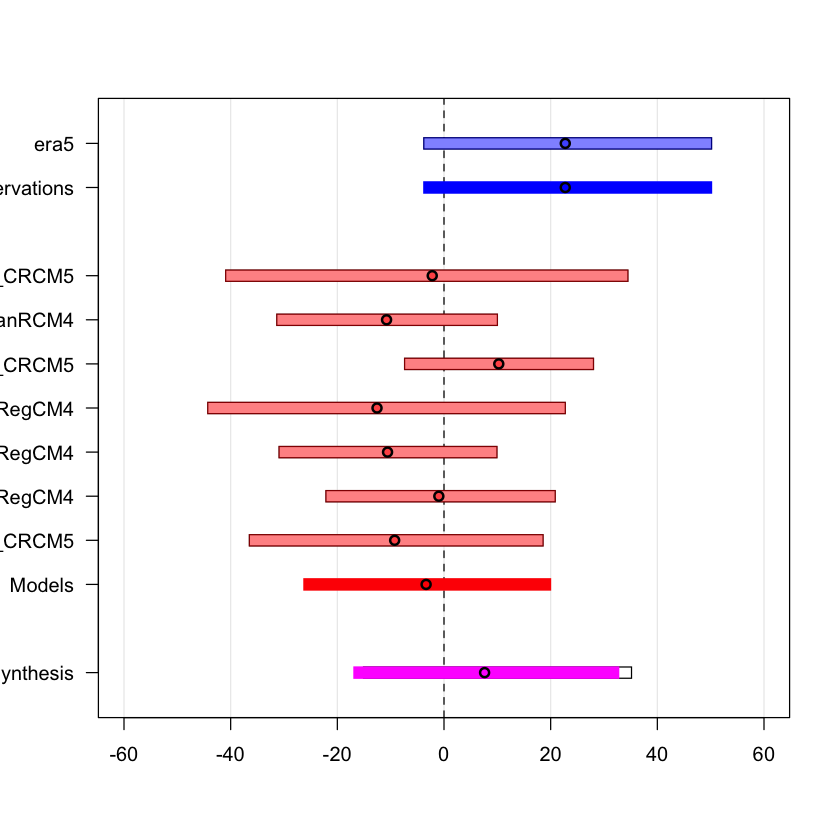

In [25]:
plot_synthesis(synth_dI_attr)

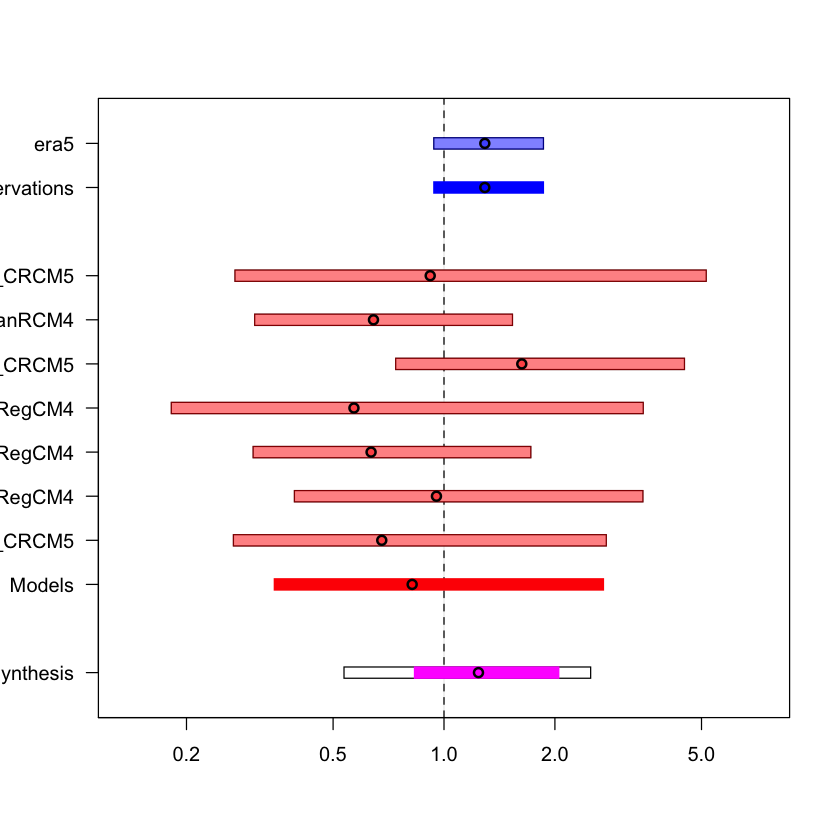

In [26]:
plot_synthesis(synth_PR_attr)

In [27]:
?plot_synthesis

plot_synthesis {rwwa},R Documentation
synth,Either a list containing the results of a synthesis carrier out using the 'synthesis' function or a data.frame containing the raw output from a synthesis on the Climate Explorer.
xlim,"Vector of length 2 (optional) giving range of x coordinates. If not provided, will be estimated from the range of the synthesised values."
lwd,Scalar: width of line to be used for each bar. Default is 10.
xlab,String with which to label the x axis. Default is an empty string.
main,String: main title of plot. Default is an empty string.
add_space,"Boolean: add a blank row between the observations, models and overall synthesis? Default is T."
log,"Boolean (optional unless using output from Climate Explorer): should x axis be plotted on a log scale? Default is NA, with value determined by the type of synthesis (PR = T, rel/abs = F)."
hide_labels,Boolean: Hide the model names on the y axis? Default is F (show labels)


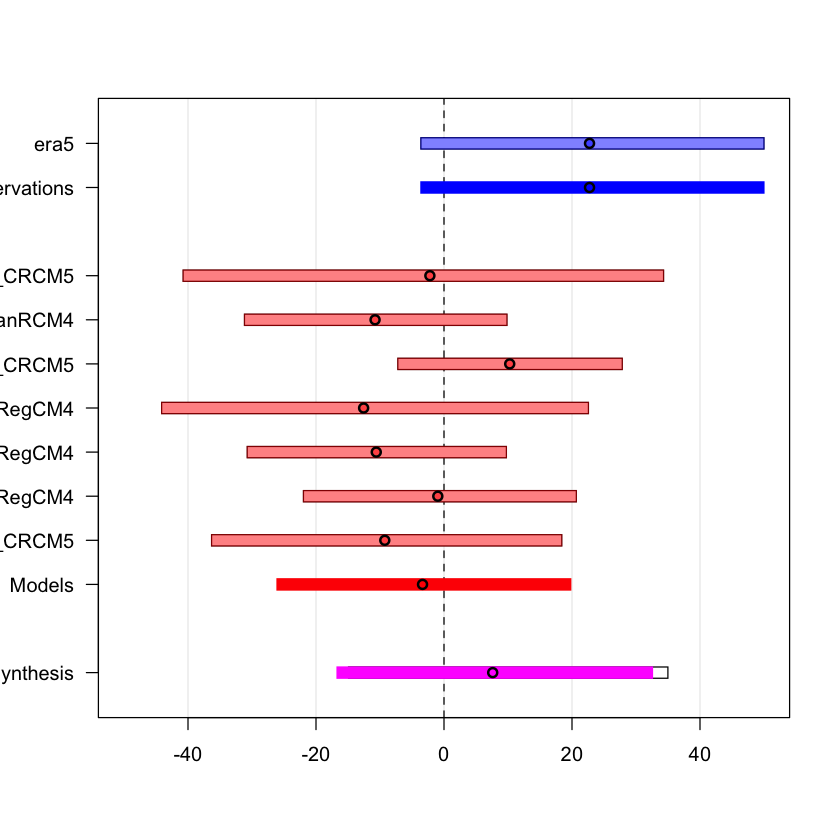

In [31]:
plot_synthesis(synth_dI_attr, xlim = c(-50,50))

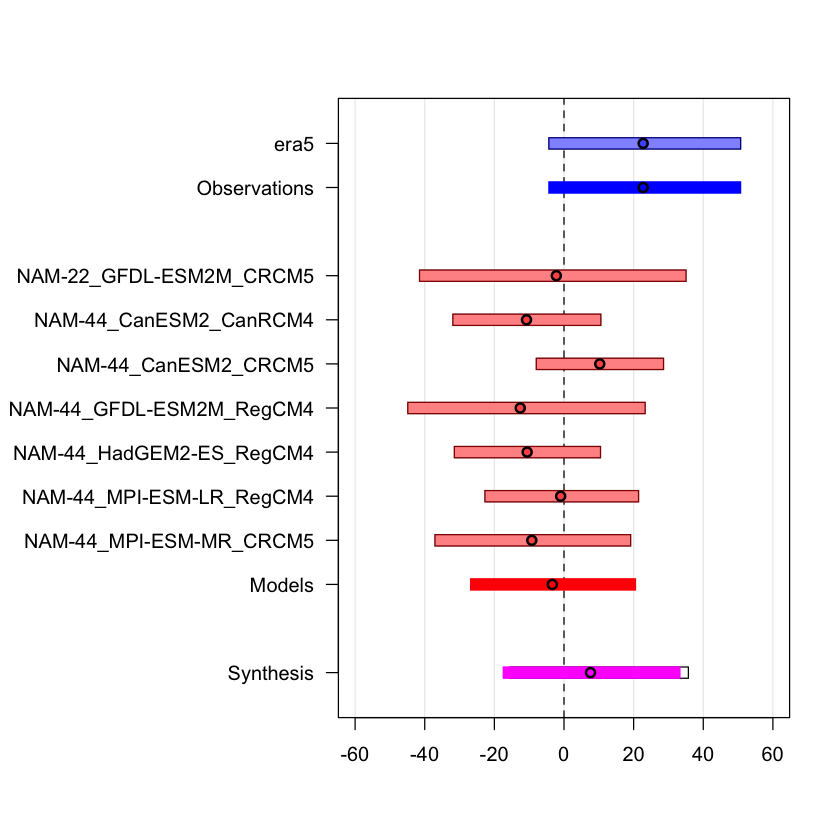

In [32]:
par(oma = c(0,10,0,0))
plot_synthesis(synth_dI_attr)

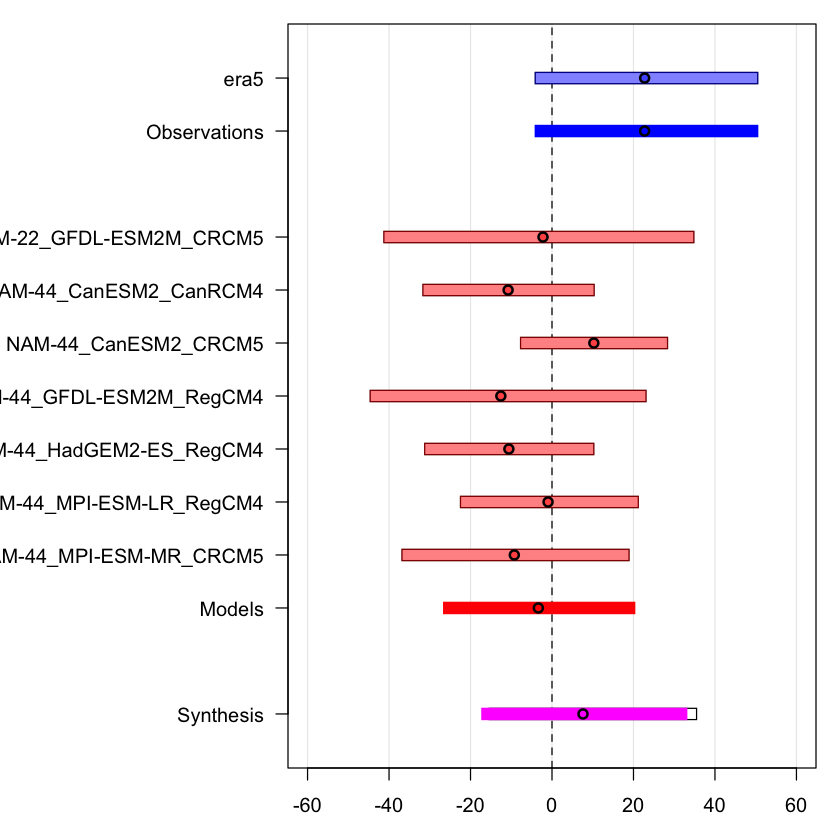

In [33]:
par(oma = c(0,10,0,0), mar = c(3,2,1,1))
plot_synthesis(synth_dI_attr)

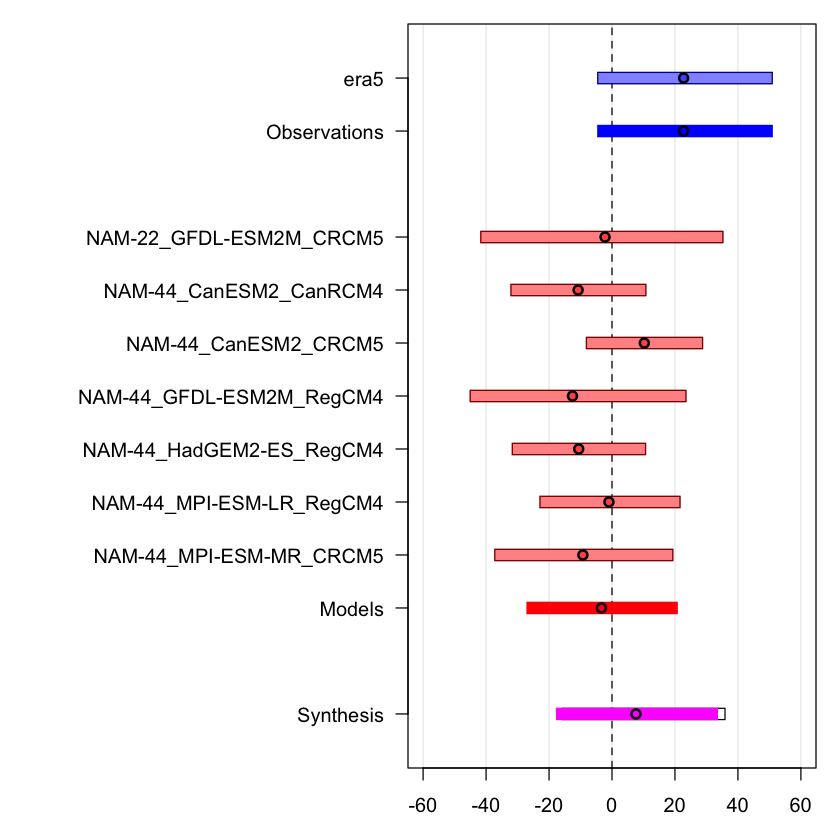

In [36]:
par(oma = c(0,15,0,0), mar = c(3,2,1,1))
plot_synthesis(synth_dI_attr)

In [37]:
# create a .png file from the data
png("synth_attr.png", height = 360, width = 360); {
    par(oma = c(0,13,0,0), mar = c(3,2,1,1))
    plot_synthesis(synth_dI_attr)
}; dev.off()

pdf 
  2

In [40]:
# add a meaningful x-axis label
png("synth_attr2.png", height = 360, width = 360); {
    par(oma = c(0,13,0,0), mar = c(4.5,2,1,1))
    plot_synthesis(synth_dI_attr, xlab = "Change in intensity")
}; dev.off()

pdf 
  2

In [41]:
# add a title (need to make top margin larger to make it visible)
png("synth_attr.png", height = 360, width = 570); {
    par(oma = c(0,13,0,0), mar = c(3,2,3,1))
    plot_synthesis(synth_dI_attr, main = "Change in intensity")
}; dev.off()

pdf 
  2

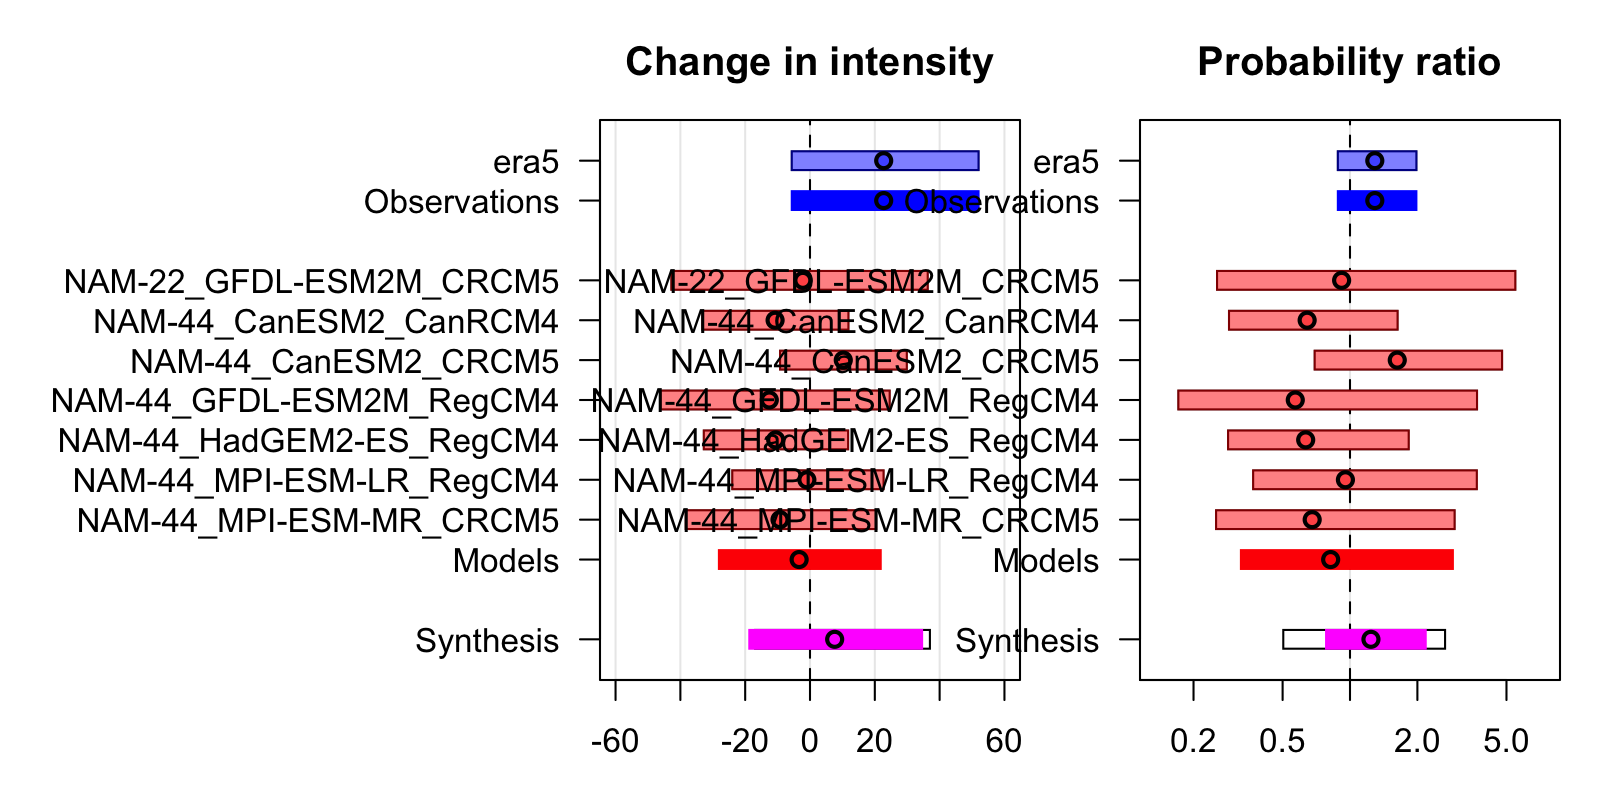

In [42]:
# plot both side by side
prep_window(c(1,2))
par(oma = c(0,13,0,0), mar = c(3,2,3,1))
plot_synthesis(synth_dI_attr, main = "Change in intensity")
plot_synthesis(synth_PR_attr, main = "Probability ratio")

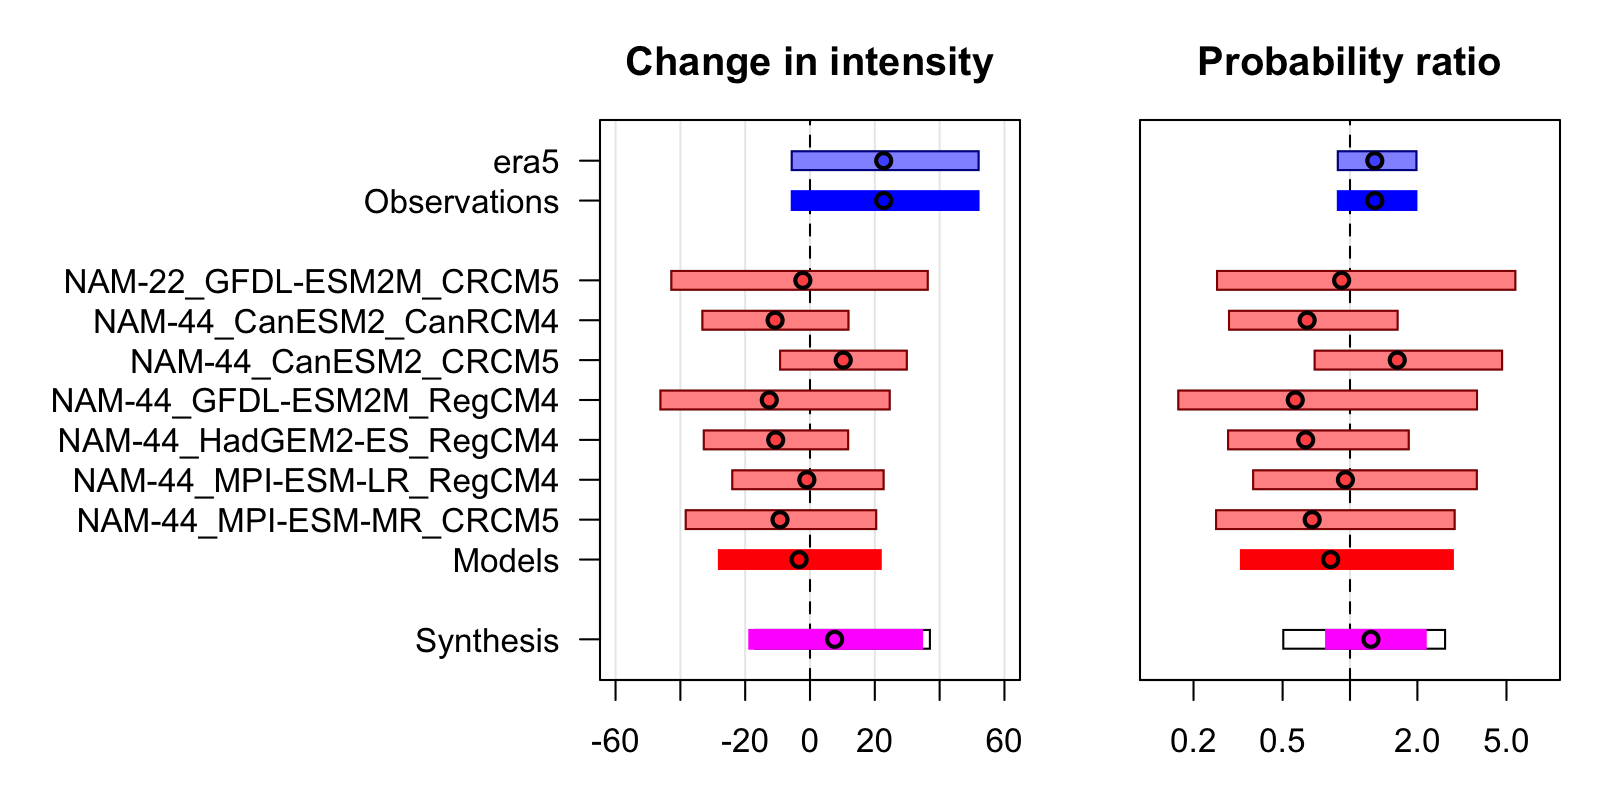

In [43]:
# fix the axis labels
prep_window(c(1,2))
par(oma = c(0,13,0,0), mar = c(3,2,3,1))
plot_synthesis(synth_dI_attr, main = "Change in intensity")
plot_synthesis(synth_PR_attr, main = "Probability ratio", hide_labels = T)

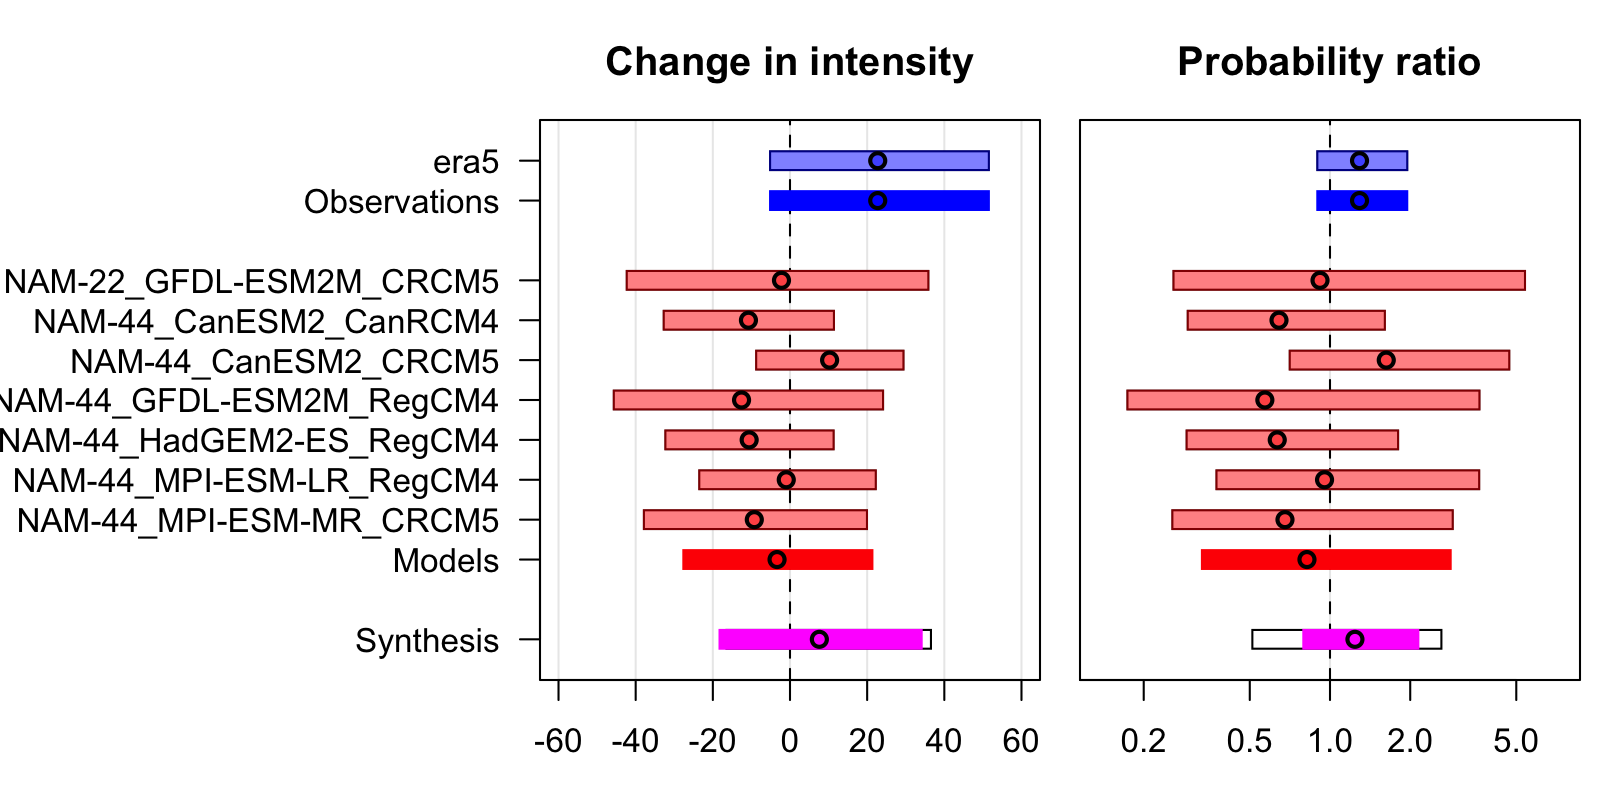

In [44]:
# you can shrink the whitespace in between by playing with the margins
prep_window(c(1,2))
par(oma = c(0,13,0,0), mar = c(3,0.5,3,0.5))
plot_synthesis(synth_dI_attr, main = "Change in intensity")
plot_synthesis(synth_PR_attr, main = "Probability ratio", hide_labels = T)

In [45]:
# can wrap 'prep_window' to output .png
png("synth_both.png", height = 360, width = 570); {
    prep_window(c(1,2), oma = c(0,13,0,0), mar = c(3,0.5,3,0.5))
    plot_synthesis(synth_dI_attr, main = "Change in intensity")
    plot_synthesis(synth_PR_attr, main = "Probability ratio", hide_labels = T)
}; dev.off()

pdf 
  2

In [46]:
# change in intensity from present-future
synth_dI_proj <- synthesis(obs_in = NA,
                           models_in = df_models[,grepl("proj_dI", colnames(df_models))],
                           synth_type = synthesis_type)

In [47]:
synth_dI_proj

,group,model,est,lower,upper,l_wb,u_wb
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,models,NAM-22_GFDL-ESM2M_CRCM5,-8.3477599,-28.00697,12.241288,-28.00697,12.241288
4,models,NAM-44_CanESM2_CanRCM4,0.1601069,-11.47960,12.618925,-11.47960,12.618925
5,models,NAM-44_CanESM2_CRCM5,-1.9022614,-12.47713,7.939475,-12.47713,7.939475
6,models,NAM-44_GFDL-ESM2M_RegCM4,-7.9718685,-23.74851,8.266058,-23.74851,8.266058
7,models,NAM-44_HadGEM2-ES_RegCM4,2.4835592,-10.74449,17.198157,-10.74449,17.198157
8,models,NAM-44_MPI-ESM-LR_RegCM4,3.5617249,-10.59928,16.499304,-10.59928,16.499304
9,models,NAM-44_MPI-ESM-MR_CRCM5,-5.3291427,-20.47018,10.330167,-20.47018,10.330167
10,model_synth,Models,-1.5732719,-15.09988,12.188817,NA,NA


In [63]:
# change in likelihood from past-present
synth_PR_proj <- synthesis(obs_in = NA,
                           models_in = df_models[,grepl("proj_PR", colnames(df_models))],
                           synth_type = "PR")

In [64]:
synth_PR_proj

,group,model,est,lower,upper,l_wb,u_wb
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,models,NAM-22_GFDL-ESM2M_CRCM5,0.7104755,0.2631214,1.559385,0.2631214,1.559385
4,models,NAM-44_CanESM2_CanRCM4,1.0067082,0.5979720,1.651954,0.5979720,1.651954
5,models,NAM-44_CanESM2_CRCM5,0.9157204,0.5334779,1.435800,0.5334779,1.435800
6,models,NAM-44_GFDL-ESM2M_RegCM4,0.6541672,0.2489646,1.446308,0.2489646,1.446308
7,models,NAM-44_HadGEM2-ES_RegCM4,1.1120318,0.6027044,1.978828,0.6027044,1.978828
8,models,NAM-44_MPI-ESM-LR_RegCM4,1.1705987,0.6032821,2.045956,0.6032821,2.045956
9,models,NAM-44_MPI-ESM-MR_CRCM5,0.7816637,0.3467002,1.554280,0.3467002,1.554280
10,model_synth,Models,0.9438640,0.4805796,1.685600,NA,NA


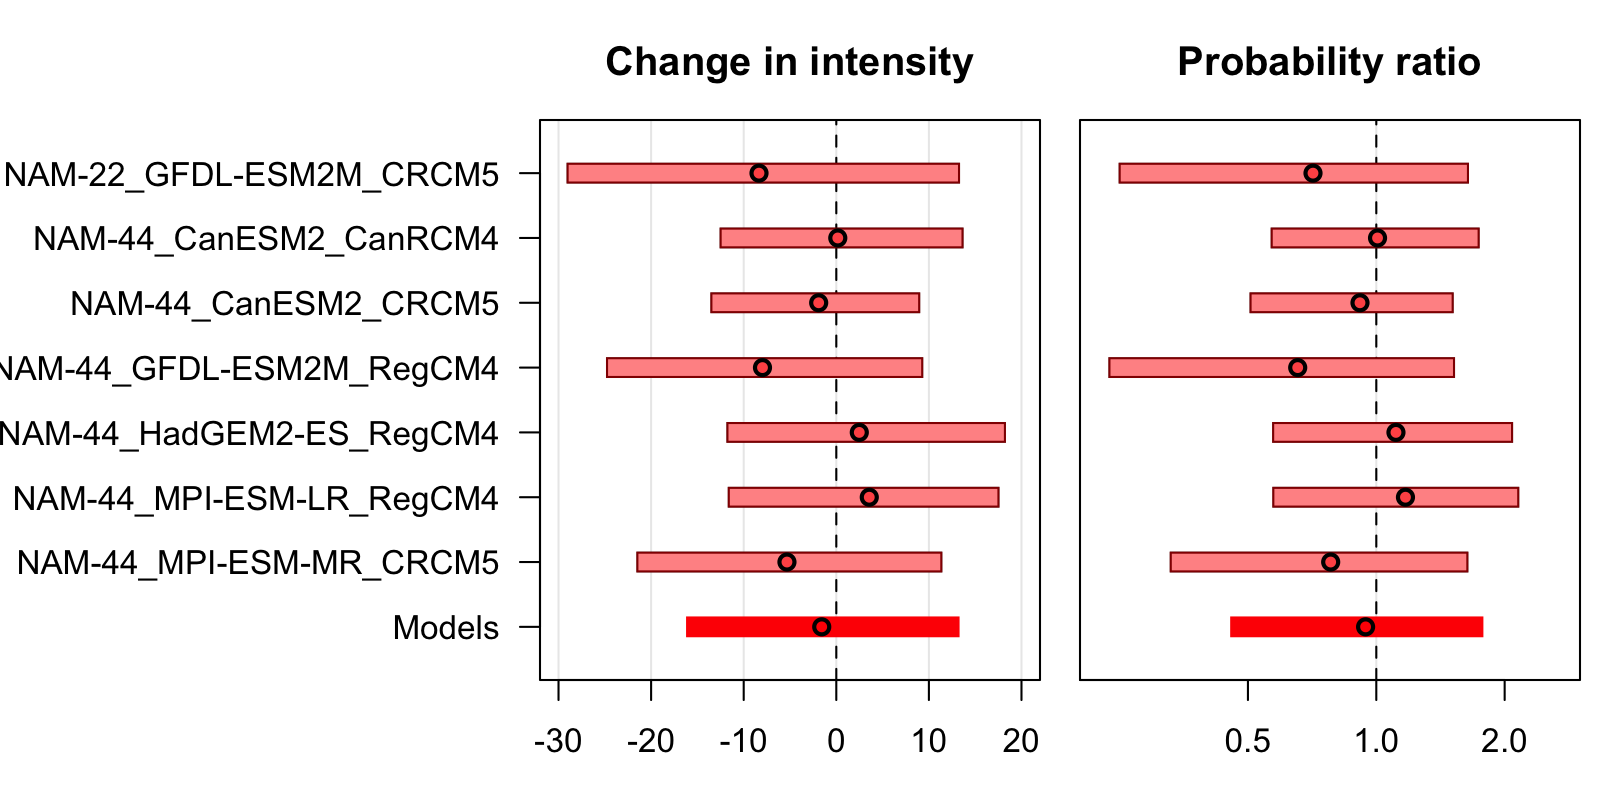

In [65]:
# you can shrink the whitespace in between by playing with the margins
prep_window(c(1,2))
par(oma = c(0,13,0,0), mar = c(3,0.5,3,0.5))
plot_synthesis(synth_dI_proj, main = "Change in intensity", add_space = F)
plot_synthesis(synth_PR_proj, main = "Probability ratio", hide_labels = T, add_space = F)

In [62]:
df_models

,Include,eval_sigma0_est,eval_sigma0_lower,eval_sigma0_upper,rp_value,attr_PR_est,attr_PR_lower,attr_PR_upper,attr_dI.abs_est,attr_dI.abs_lower,attr_dI.abs_upper,proj_PR_est,proj_PR_lower,proj_PR_upper,proj_dI.abs_est,proj_dI.abs_lower,proj_dI.abs_upper,aic,ymax
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
NAM-22_GFDL-ESM2M_CRCM5,y,44.38489,38.43341,49.48113,107.00156,0.9173883,0.2805309,4.971504,-2.2066012,-39.881649,33.426981,0.7104755,0.2631214,1.559385,-8.3477599,-28.00697,12.241288,1168.429,2099
NAM-44_CanESM2_CanRCM4,y,40.19657,34.23958,44.72126,155.50986,0.6435560,0.3172621,1.481076,-10.7707002,-30.296753,8.957120,1.0067082,0.5979720,1.651954,0.1601069,-11.47960,12.618925,1143.932,2060
NAM-44_CanESM2_CRCM5,y,39.37649,33.46375,45.14717,151.56745,1.6260360,0.7658758,4.339289,10.2677156,-6.336199,26.974154,0.9157204,0.5334779,1.435800,-1.9022614,-12.47713,7.939475,1126.914,2060
NAM-44_GFDL-ESM2M_RegCM4,y,35.97144,28.30668,41.92568,96.21781,0.5695896,0.1884293,3.353534,-12.5594936,-43.239178,21.688678,0.6541672,0.2489646,1.446308,-7.9718685,-23.74851,8.266058,1110.654,2060
NAM-44_HadGEM2-ES_RegCM4,y,38.10545,25.90549,52.19555,95.76622,0.6339448,0.3142411,1.660705,-10.5846282,-29.867503,8.869665,1.1120318,0.6027044,1.978828,2.4835592,-10.74449,17.198157,1144.449,2060
NAM-44_MPI-ESM-LR_RegCM4,y,35.77264,28.56565,41.99948,109.01231,0.9539081,0.4066921,3.346124,-0.9680477,-21.082154,19.799067,1.1705987,0.6032821,2.045956,3.5617249,-10.59928,16.499304,1130.876,2059
NAM-44_MPI-ESM-MR_CRCM5,y,39.45226,31.32883,45.66949,126.44514,0.6777665,0.2777808,2.662241,-9.2525027,-35.436609,17.520675,0.7816637,0.3467002,1.554280,-5.3291427,-20.47018,10.330167,1158.029,2060
